Here's how chunking and context evaluation work together as a single debugging discipline — using procurement as the running domain throughout.

---

## Why chunking exists

RAG systems split documents into chunks because language models have finite context windows and because embedding search works best on focused, semantically coherent units of text. A 200-page tender document can't be stuffed wholesale into a prompt; instead, relevant pieces are retrieved on demand.

The critical insight: **chunking is a lossy compression of meaning**. Every split discards some relational information. The question isn't whether information is lost — it always is — but whether enough survives for the retrieved piece to be useful.

---

## What makes a good chunk vs. a bad one

A good chunk is self-contained enough that someone reading it cold — with no surrounding pages — can understand what it's asserting. A bad chunk is one whose meaning depends on context that was cut away.

In procurement documents, natural good boundaries are: a complete clause with its heading, a full evaluation criterion with its weighting and description, a complete payment schedule row. Natural bad breaks are: mid-clause splits, separating a table header from its data rows, cutting a definition from the term it defines.


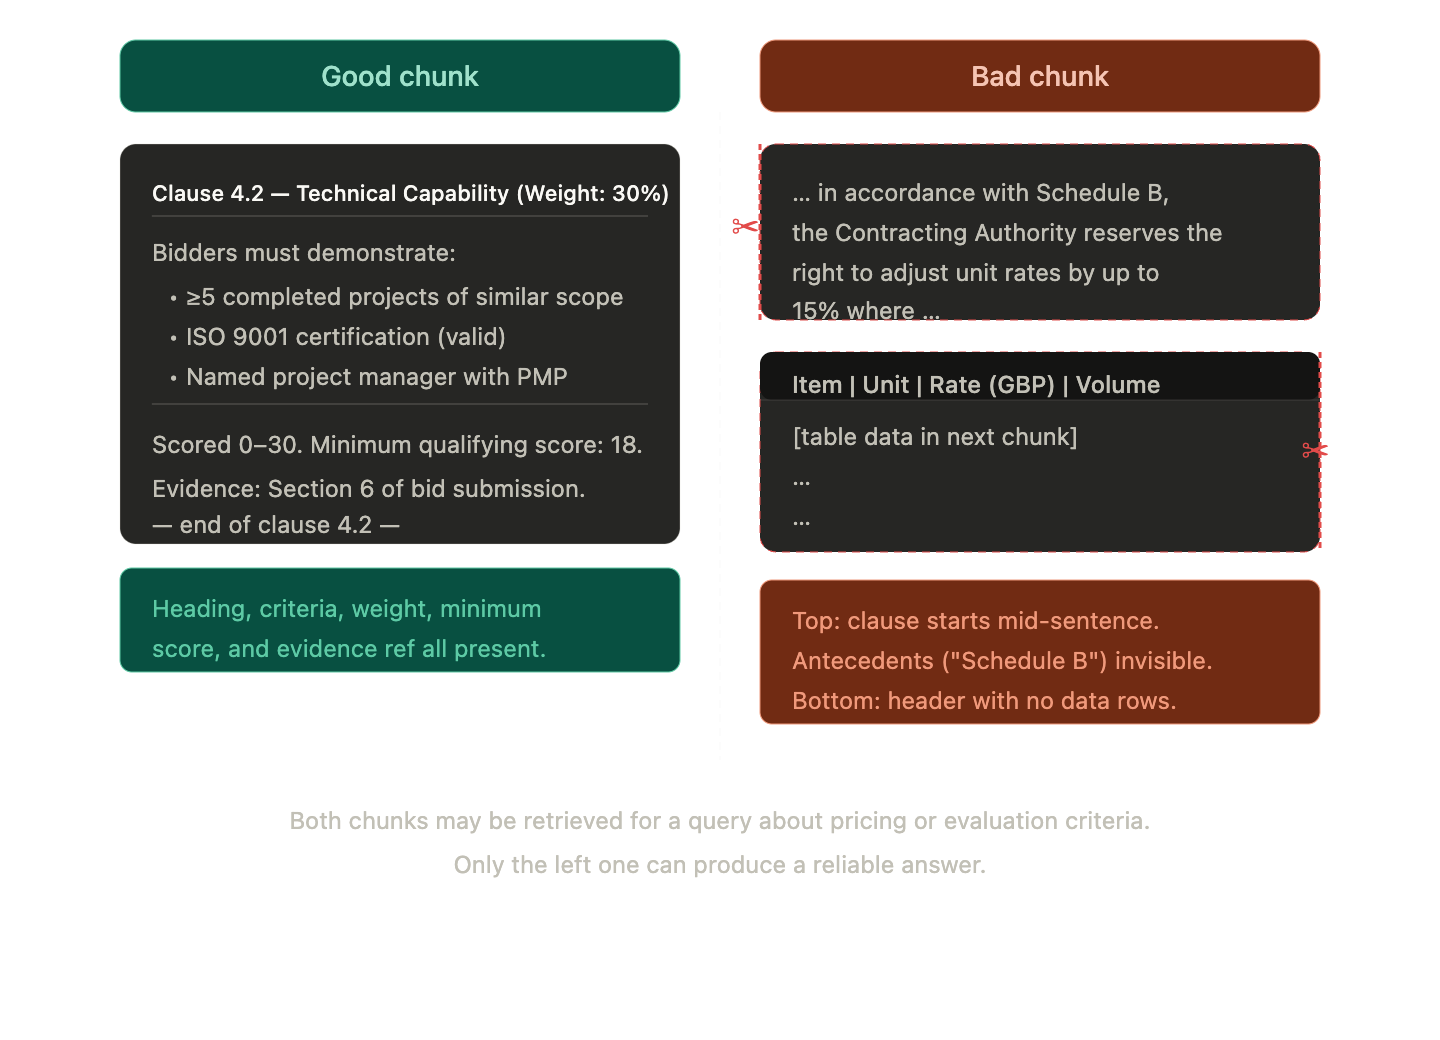
---

## Why a correctly retrieved chunk can still produce a poor answer

This is the subtler failure — and the more dangerous one, because the system looks like it's working. The right chunk arrived. The model read it. The answer is still wrong.

There are three mechanisms:

**Incompleteness.** The chunk contains a true fact, but not enough of the truth. A retrieved chunk might correctly state that "payment is due 30 days from invoice." What it doesn't include — because it was chunked away — is the clause two paragraphs later: "except for milestone payments, which follow the Schedule C release schedule." An answer built only on the retrieved chunk will be confidently, partially wrong.

**Noise.** The chunk contains the target information but also irrelevant or contradicting boilerplate that throws the model off. Procurement documents are notoriously repetitive — definitions appear in multiple annexes, standard clauses get repeated with local modifications. A retrieved chunk might contain an outdated unit rate that was superseded by an addendum, but the chunk gives no signal that it's the non-authoritative version.

**Missing surrounding context.** The chunk's meaning depends on something that was cut away. Pronouns without referents ("it shall comply"), defined terms without their definitions ("the Contracting Authority" as defined in Clause 1), tables without their headers, conditions without their triggers ("in the event described in 3.1(b)…") — all of these produce answers that are technically drawn from the right document location but are semantically incomplete or misread.

---

## Realistic procurement example: both failure types

**Scenario:** A user asks *"What is the penalty for late delivery under this framework contract?"*

**Document structure (simplified):**
- Clause 7.1 — Performance Standards
- Clause 7.2 — Liquidated Damages *(defines the penalty formula)*
- Clause 7.3 — Force Majeure exceptions
- Annex D — Damages Calculation Table *(actual rates by product category)*

**Wrong chunk retrieved** — chunk from Clause 7.1:

> *"The Supplier shall deliver all goods and services within the timescales specified in the Call-Off Order. Failure to meet performance standards will be addressed in accordance with the Authority's performance management framework."*

This is genuinely the wrong chunk. It mentions failure but contains no penalty. The model will either say "I couldn't find a specific penalty figure" (hallucination-avoidant but unhelpful) or invent a number (dangerous). The retrieval failed because the query matched on the word "penalty" near "performance standards" rather than finding the liquidated damages clause.

**Right chunk, unusable context** — chunk from Clause 7.2:

> *"…at the rate specified in the applicable table, calculated per calendar day from the date of the Scheduled Delivery Date until the date of actual delivery or termination, whichever occurs first. The total liability under this clause shall not exceed the cap set out in Clause 12."*

This is the correct location. But the chunk starts mid-sentence (the rate specification is in Annex D, which wasn't retrieved), references "the applicable table" (not present), and defers the liability cap to Clause 12 (also absent). The model now has the mechanism but none of the numbers, and will produce an answer that is structurally correct ("there is a daily penalty capped at an amount in Clause 12") but completely unusable for anyone trying to calculate actual exposure.---


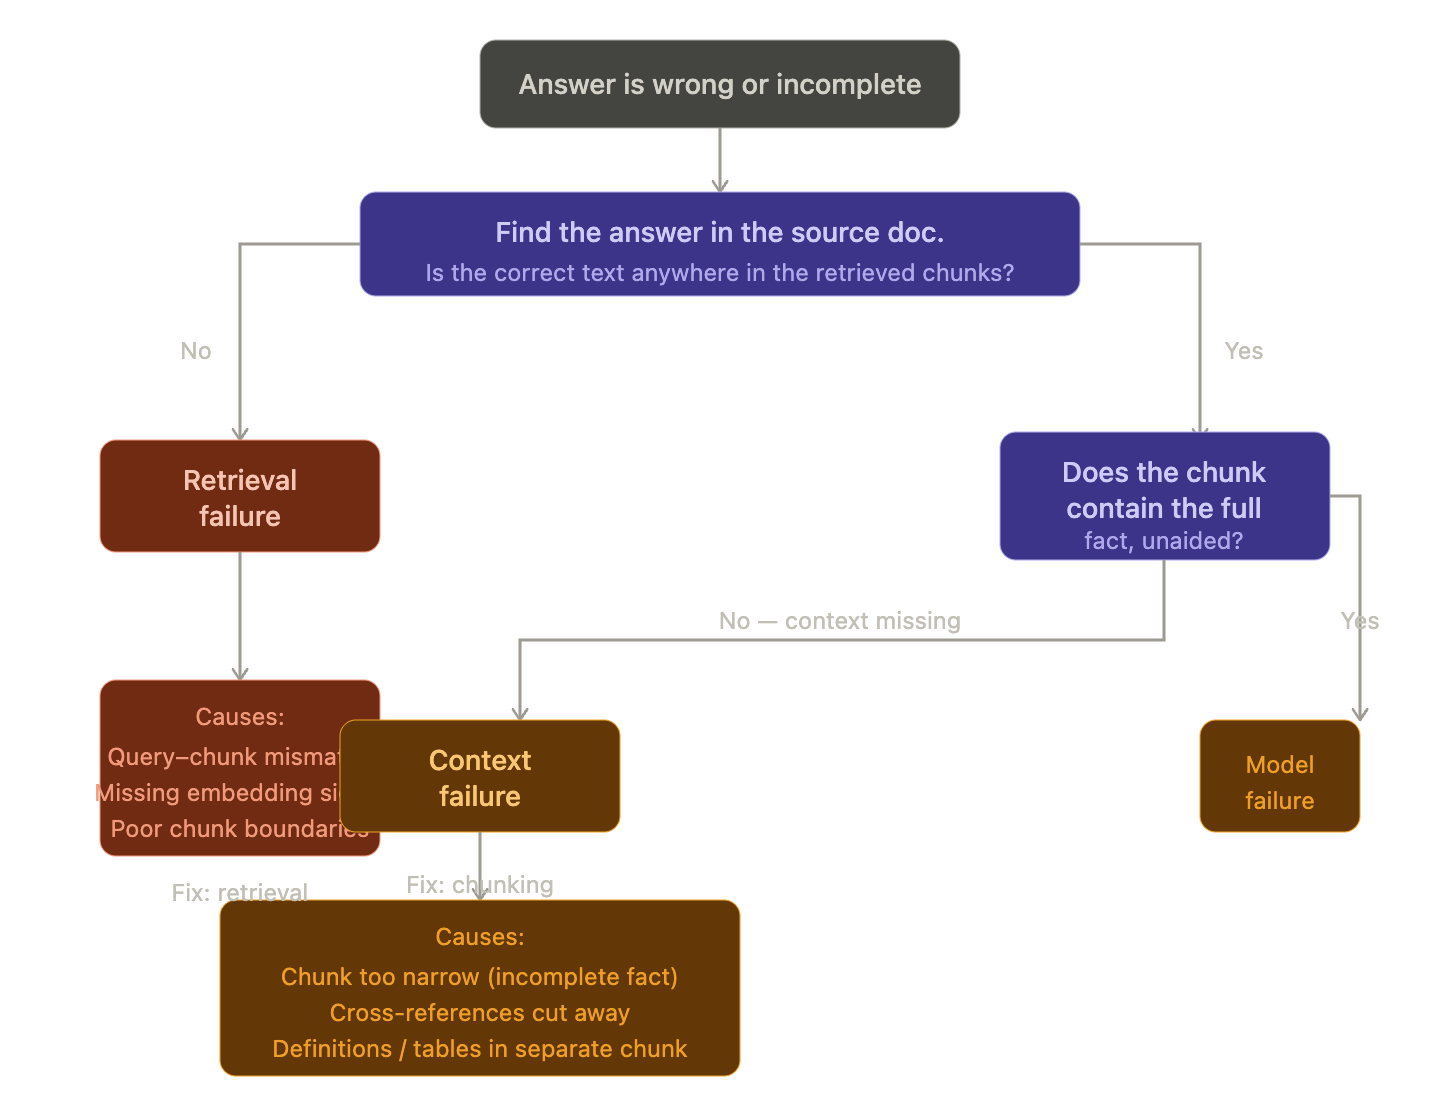

## How to tell which failure you have

When an answer is wrong, the diagnostic question is: **does the correct information appear anywhere in the retrieved chunks?**

Open your retrieval logs (or add temporary logging if you don't have them). Inspect the actual chunks that were passed to the model for the failed query.

**If the correct answer text is absent from all retrieved chunks** — you have a retrieval failure. The embedding model didn't connect your query to the right document location. Fixes live in the retrieval layer: chunk boundary redesign, query rewriting, hybrid search, metadata filters, re-ranking.

**If the correct answer text is present in a retrieved chunk but the answer is still wrong** — you have a context failure. The chunk arrived but couldn't be used. Now ask: does the chunk make sense in isolation? If a colleague saw only that chunk with zero surrounding pages, could they answer the question accurately? If not, the chunk is structurally dependent on content that was left behind.

Specific signals that distinguish the sub-types:

A **mid-document reference** in the chunk ("as per Clause 3.4", "see Annex B", "at the rates in the table above") almost always signals context failure — the dependency was severed by the chunk boundary.

A **dangling pronoun or undefined term** ("the Authority", "the Scheduled Date", "it") signals the same thing — the antecedent is in a prior chunk.

A **partially correct answer** — right structure, wrong or missing numbers — often means the chunk contains the mechanism (formula, clause, procedure) but a referenced table or definition was split into a different chunk and wasn't retrieved.

A **completely hallucinated answer** in the face of relevant-seeming source material often means the retrieved chunks were noisy — they matched the query's surface terms but contained the wrong version of the clause (e.g., a standard template version, not the executed contract version), causing the model to confabulate rather than find a clear signal.

---

## Procurement-specific chunking guidance

Tender documents have a predictable structure that makes chunking decisions less ambiguous than general prose:

Each numbered clause should be its own chunk where possible, including its heading. If a clause references a definition (in Clause 1) or a schedule (in an annex), that reference should either be resolved by including the definition inline via metadata enrichment, or flagged in the chunk text so the model knows to treat the answer as incomplete.

Evaluation criteria sections are high-stakes — never split a criterion from its weighting, its minimum score, or its evidence requirements. These are atomic units for any question about scoring.

Bill of quantities and rate schedules should be chunked to keep table headers and their data rows together. A header row without data is meaningless; data rows without a header are ambiguous.

Addenda and amendments should be stored with metadata that flags them as superseding earlier chunks, and preferably as overlapping chunks that include the clause they modify — otherwise a retrieval hit on the original clause produces outdated information with no indication it was revised.

The practical test before deploying any chunking strategy on a new document type: write the ten most common queries users will ask, retrieve the chunks those queries return, and read each chunk cold. If you can answer the question from the chunk alone, the chunking is working. If you reach for adjacent pages, your chunk boundaries need to move.